In [1]:
#  Licensed to the Apache Software Foundation (ASF) under one
#  or more contributor license agreements.  See the NOTICE file
#  distributed with this work for additional information
#  regarding copyright ownership.  The ASF licenses this file
#  to you under the Apache License, Version 2.0 (the
#  "License"); you may not use this file except in compliance
#  with the License.  You may obtain a copy of the License at
#
#      http://www.apache.org/licenses/LICENSE-2.0
#
#  Unless required by applicable law or agreed to in writing, software
#  distributed under the License is distributed on an "AS IS" BASIS,
#  WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
#  See the License for the specific language governing permissions and
# limitations under the License.

<center>
<img src="https://hudi.apache.org/assets/images/hudi-logo-medium.png" alt="Hudi logo" width="100%" height="320"/>
</center>

# What's New in Apache Hudi 1.2.0

Apache Hudi **1.2.0** extends the open lakehouse toward **AI and multimodal data** while keeping the same transactional guarantees Hudi tables have always had. This notebook is a hands-on tour of the headline, Spark-facing features, using native Spark SQL DDL against MinIO (S3-compatible storage):

![Hudi 1.2.0 Features](images/hudi_1_2_0_features.jpg)

### Setting up the Environment
We load `utils.py` and start a SparkSession pinned to the Hudi 1.2.0 bundle. The standalone master URL and driver/executor memory come from `spark-defaults.conf`; `get_spark_session` only adds the Hudi bundle and catalog wiring (incl. Hive support, so the `spark_catalog.default.*` catalog tables below resolve against the shared Hive Metastore).

The cell also quiets two benign-but-noisy Hudi loggers so the table writes below don't flood the notebook output.

In [2]:
hudi_1_2_0_base_path = f"s3://warehouse/hudi_1_2_0"

In [3]:
%run utils.py

In [4]:
# Pin the Hudi bundle to 1.2.0 (downloaded from Maven Central on first use if not pre-baked).
# include_lance=True also resolves the Lance Spark bundle, needed by the Lance section below.
spark = get_spark_session("Hudi 1.2.0 New Features", hudi_version="1.2.0", include_lance=True)

_Configurator = spark._jvm.org.apache.logging.log4j.core.config.Configurator
_Level = spark._jvm.org.apache.logging.log4j.Level

for _logger in (
    "org.apache.hudi.common.table.HoodieTableConfig",
    "org.apache.hudi.HoodieSparkSqlWriter",
    "org.apache.hudi.HoodieSparkSqlWriterInternal",
    "org.apache.hadoop.hive.ql.session.SessionState",
    "org.apache.hudi.common.model.HoodiePayloadConfig"
    ):
    _Configurator.setLevel(_logger, _Level.ERROR)

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/06/22 08:14:38 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


SparkSession started with app name: Hudi 1.2.0 New Features, Spark version: 4.0.2, Hudi version: 1.2.0


## Unstructured and semi-structured column types

Hudi 1.2.0 supports three column types for unstructured and semi-structured data.

1. VARIANT
2. BLOB
3. VECTOR

### 1. Native VARIANT Type for Semi-Structured JSON

Prior to 1.2.0, storing highly variable or nested JSON payloads required flat text strings or complex nested `STRUCT` definitions that broke down when upstream schemas drifted. The native `VARIANT` type allows **schema-on-read** querying with raw binary storage performance.

```sql
VECTOR(dimensions [, element_type])
```

- **`dimensions`** — a strict integer defining the fixed array width (e.g. `768` or `1024` for standard LLM text/image embeddings).
- **`element_type`** — the precision of the numeric array. Hudi supports `FLOAT` (the default), `DOUBLE`, and `INT8` / `BYTE` for quantized embeddings.
  
VARIANT columns support `UPDATE`, `DELETE`, and `MERGE` on both COW and MOR tables.

Engine support: native VARIANT keyword on Spark 4.0+; on Spark 3.x, VARIANT surfaces as STRUCT<metadata: BINARY, value: BINARY> and remains readable.

**Note:** VARIANT columns are not supported on Lance-backed tables. Use Parquet for tables that contain VARIANT columns.

In [5]:
variant_table_name = "hudi_variant_table"
variant_table_path = os.path.join(hudi_1_2_0_base_path, variant_table_name)

variant_table_ddl = f"""
    CREATE TABLE IF NOT EXISTS {variant_table_name} (
        id INT,
        event_type STRING,
        payload VARIANT
    ) USING hudi
    TBLPROPERTIES (
        type = 'cow',
        primaryKey = 'id',
        preCombineField = 'id'
    )
    LOCATION '{variant_table_path}'
"""

create_table(variant_table_ddl, variant_table_name, variant_table_path)

26/06/22 08:14:40 WARN MetricsConfig: Cannot locate configuration: tried hadoop-metrics2-s3a-file-system.properties,hadoop-metrics2.properties
SLF4J: Failed to load class "org.slf4j.impl.StaticLoggerBinder".
SLF4J: Defaulting to no-operation (NOP) logger implementation
SLF4J: See http://www.slf4j.org/codes.html#StaticLoggerBinder for further details.


✓ Table 'hudi_variant_table' dropped successfully.
✓ Table 'hudi_variant_table' created successfully.

Schema for 'hudi_variant_table':



col_name,data_type,comment
_hoodie_commit_time,string,None
_hoodie_commit_seqno,string,None
_hoodie_record_key,string,None
_hoodie_partition_path,string,None
_hoodie_file_name,string,None
id,int,None
event_type,string,None
payload,variant,None
,,
# Detailed Table Information,,


`parse_json()` turns each JSON string into a genuine `VARIANT` value. Notice the two rows carry completely different structures (nested `coordinates` vs. a `tags` array) with no schema migration:

In [6]:
variant_table_insert_query = f"""
    INSERT INTO {variant_table_name} VALUES 
    (1, 'click', parse_json('{{"element": "submit_btn", "coordinates": {{"x": 10, "y": 25}}}}')),
    (2, 'purchase', parse_json('{{"item_id": 995, "amount": 49.99, "currency": "USD", "tags": ["promo", "summer"]}}'))
"""

insert_data(variant_table_insert_query, variant_table_name)

# WARNING: Unable to get Instrumentation. Dynamic Attach failed. You may add this JAR as -javaagent manually, or supply -Djdk.attach.allowAttachSelf
# WARNING: Unable to attach Serviceability Agent. sun.jvm.hotspot.memory.Universe.getNarrowOopBase()
✓ Data inserted successfully into 'hudi_variant_table'. Total Records: 2


Query individual fields with `variant_get(col, '$.path', 'type')`, which navigates the JSON-style path and casts to the type you ask for. Fields a row doesn't have simply return `NULL`:

In [7]:
variant_df = spark.sql(f"""
    SELECT 
        id, 
        event_type,
        variant_get(payload, '$.element', 'string') AS button_clicked,
        variant_get(payload, '$.amount', 'double') AS transaction_amount,
        variant_get(payload, '$.coordinates', 'string') AS coordinates
    FROM {variant_table_name}
""")

display(variant_df)

id,event_type,button_clicked,transaction_amount,coordinates
1,click,submit_btn,NaN,"{""x"":10,""y"":25}"
2,purchase,None,49.99,None


### 2. `BLOB` Type for Unstructured Binary Objects

Hudi 1.2.0 stores large raw binary elements (images, audio, documents) via the native `BLOB` type. Physically a `BLOB` column is a **struct** — `struct<type, data, reference>` — supporting **inline** storage (bytes held in `data`) and **out-of-line** storage (a `reference` pointer to an external object), so queries can read metadata without materializing the bytes.

BLOB columns are excluded from column-stats indexing.

The binary encoding preserves the original document structure and types without requiring a fixed schema, so each row can carry a different shape.

In [8]:
blob_table_name = "hudi_blob_table"
blob_table_path = os.path.join(hudi_1_2_0_base_path, blob_table_name)

blob_table_ddl = f"""
    CREATE TABLE IF NOT EXISTS {blob_table_name} (
        asset_id    INT,
        file_name   STRING,
        mime_type   STRING,
        file_size   BIGINT,
        content     BLOB
    
    ) USING hudi
    TBLPROPERTIES (
        type = 'cow',
        primaryKey = 'asset_id'
    )
    LOCATION '{blob_table_path}'
"""

create_table(blob_table_ddl, blob_table_name, blob_table_path)

✓ Table 'hudi_blob_table' dropped successfully.
✓ Table 'hudi_blob_table' created successfully.

Schema for 'hudi_blob_table':



col_name,data_type,comment
_hoodie_commit_time,string,None
_hoodie_commit_seqno,string,None
_hoodie_record_key,string,None
_hoodie_partition_path,string,None
_hoodie_file_name,string,None
asset_id,int,None
file_name,string,None
mime_type,string,None
file_size,bigint,None
content,"struct<type:string,data:binary,reference:struct<external_path:string,offset:bigint,length:bigint,managed:boolean>>",None


Understanding BLOB Internal Structure

The BLOB type in Hudi is internally represented as:
    
```text
STRUCT<
    TYPE: STRING,           -- 'INTERNAL' or 'EXTERNAL'
    DATA: BINARY,           -- The actual binary content (for INTERNAL type)
    REFERENCE: STRUCT<      -- External reference (for EXTERNAL type)
        EXTERNAL_PATH: STRING,
        OFFSET: BIGINT,
        LENGTH: BIGINT,
        MANAGED: BOOLEAN
    >
>
```

A `BLOB` value is built with `named_struct`: `type = 'INLINE'` for inline storage, the bytes in `data`, and a (typed) `NULL` `reference` since we aren't pointing at an external object. The `type` field is an enum — it must be the exact symbol `INLINE` (lowercase fails Avro conversion). Plain `BINARY` does **not** auto-coerce into a `BLOB`, so this struct form is required.

The default read mode for inline BLOBs is controlled by hoodie.read.blob.inline.mode (defaults to DESCRIPTOR; set to CONTENT to materialize inline bytes on every scan). Engine support: Spark for read and write. Hive and BigQuery sync map the BLOB struct to the catalog's native struct type, but read_blob() is a Spark SQL function only.

In [9]:
from pyspark.sql.functions import col, lit, struct, when
from pyspark.sql.types import *
import base64
import os
import hashlib

def create_sample_image(width=100, height=100, color=(255, 0, 0)):
    """Create a simple image and return as binary data"""
    from PIL import Image
    import io
    
    img = Image.new('RGB', (width, height), color=color)
    img_bytes = io.BytesIO()
    img.save(img_bytes, format='PNG')
    return img_bytes.getvalue()

sample_data = [
    (1, "logo.png", "image/png", create_sample_image(200, 200, (255, 0, 0))),
    (2, "banner.png", "image/png", create_sample_image(300, 150, (0, 0, 255))),
    (3, "icon.png", "image/png", create_sample_image(64, 64, (0, 255, 0))),
    (4, "report.pdf", "application/pdf", b"%PDF-1.4 Sample PDF content"),
    (5, "config.json", "application/json", b'{"key": "value", "version": "1.0"}'),
]

rows = []
for asset_id, file_name, mime_type, binary_content in sample_data:
    row = (
        asset_id,
        file_name,
        mime_type,
        len(binary_content),
        # Create BLOB as STRUCT with INTERNAL type
        (
            "INTERNAL",                    # TYPE
            bytearray(binary_content),     # DATA
            None                           # REFERENCE (null for INTERNAL)
        )
    )
    rows.append(row)

# Define schema explicitly
blob_schema = StructType([
    StructField("asset_id", IntegerType(), False),
    StructField("file_name", StringType(), True),
    StructField("mime_type", StringType(), True),
    StructField("file_size", LongType(), True),
    StructField("content", StructType([
        StructField("TYPE", StringType(), True),
        StructField("DATA", BinaryType(), True),
        StructField("REFERENCE", StructType([
            StructField("EXTERNAL_PATH", StringType(), True),
            StructField("OFFSET", LongType(), True),
            StructField("LENGTH", LongType(), True),
            StructField("MANAGED", BooleanType(), True)
        ]), True)
    ]), True)
])

blob_df = spark.createDataFrame(rows, schema=blob_schema)

blob_df.write.format("hudi") \
    .option("hoodie.table.name", blob_table_name) \
    .mode("overwrite") \
    .save(blob_table_path)

26/06/22 08:14:51 WARN HoodiePayloadConfig: 'hoodie.payload.ordering.field' wasn't set during Hoodie payload building due to absent key field passed.
26/06/22 08:14:51 WARN HoodiePayloadConfig: 'hoodie.payload.ordering.field' wasn't set during Hoodie payload building due to absent key field passed.
                                                                                

In [10]:
blob_df1 = spark.sql(f'SELECT * FROM {blob_table_name}')
display(blob_df1)

_hoodie_commit_time,_hoodie_commit_seqno,_hoodie_record_key,_hoodie_partition_path,_hoodie_file_name,asset_id,file_name,mime_type,file_size,content
20260622081451326,20260622081451326_2_5,20260622081451326_2_0,,827ac4bb-4c26-496a-b526-2189990c4026-0_2-41-52_20260622081451326.parquet,1,logo.png,image/png,586,"(INTERNAL, [137, 80, 78, 71, 13, 10, 26, 10, 0, 0, 0, 13, 73, 72, 68, 82, 0, 0, 0, 200, 0, 0, 0, 200, 8, 2, 0, 0, 0, 34, 58, 57, 201, 0, 0, 2, 17, 73, 68, 65, 84, 120, 156, 237, 210, 65, 9, 0, 32, 0, 192, 64, 181, 127, 103, 45, 225, 16, 228, 46, 193, 30, 155, 123, 192, 125, 235, 117, 0, 127, 50, 22, 9, 99, 145, 48, 22, 9, 99, 145, 48, 22, 9, 99, 145, 48, 22, 9, 99, 145, 48, 22, 9, 99, 145, 48, 22, 9, 99, 145, ...], None)"
20260622081451326,20260622081451326_4_1,20260622081451326_4_0,,057f4343-56c0-4553-a32d-73274a8e6566-0_4-41-54_20260622081451326.parquet,2,banner.png,image/png,498,"(INTERNAL, [137, 80, 78, 71, 13, 10, 26, 10, 0, 0, 0, 13, 73, 72, 68, 82, 0, 0, 1, 44, 0, 0, 0, 150, 8, 2, 0, 0, 0, 235, 57, 34, 133, 0, 0, 1, 185, 73, 68, 65, 84, 120, 156, 237, 211, 49, 1, 0, 32, 12, 192, 176, 129, 127, 207, 67, 70, 15, 18, 5, 125, 122, 102, 118, 128, 206, 173, 3, 224, 119, 38, 132, 152, 9, 33, 102, 66, 136, 153, 16, 98, 38, 132, 152, 9, 33, 102, 66, 136, 153, 16, 98, 38, 132, 152, 9, 33, 102, 66, 136, ...], None)"
20260622081451326,20260622081451326_6_4,20260622081451326_6_0,,88b0a710-276b-4ed1-abc3-254dbd78f569-0_6-41-56_20260622081451326.parquet,3,icon.png,image/png,152,"(INTERNAL, [137, 80, 78, 71, 13, 10, 26, 10, 0, 0, 0, 13, 73, 72, 68, 82, 0, 0, 0, 64, 0, 0, 0, 64, 8, 2, 0, 0, 0, 37, 11, 230, 137, 0, 0, 0, 95, 73, 68, 65, 84, 120, 156, 237, 207, 65, 13, 0, 32, 16, 192, 176, 3, 255, 158, 65, 4, 143, 134, 100, 85, 176, 173, 57, 243, 181, 173, 3, 94, 53, 160, 53, 160, 53, 160, 53, 160, 53, 160, 53, 160, 53, 160, 53, 160, 53, 160, 53, 160, 53, 160, 53, 160, 53, 160, 53, 160, 53, 160, 53, ...], None)"
20260622081451326,20260622081451326_10_3,20260622081451326_10_0,,233c959f-0cd4-4718-93e7-b1fb1b16ac33-0_10-41-60_20260622081451326.parquet,5,config.json,application/json,34,"(INTERNAL, [123, 34, 107, 101, 121, 34, 58, 32, 34, 118, 97, 108, 117, 101, 34, 44, 32, 34, 118, 101, 114, 115, 105, 111, 110, 34, 58, 32, 34, 49, 46, 48, 34, 125], None)"
20260622081451326,20260622081451326_8_2,20260622081451326_8_0,,764efa55-7bd5-499b-8c5d-488eeaaf6713-0_8-41-58_20260622081451326.parquet,4,report.pdf,application/pdf,27,"(INTERNAL, [37, 80, 68, 70, 45, 49, 46, 52, 32, 83, 97, 109, 112, 108, 101, 32, 80, 68, 70, 32, 99, 111, 110, 116, 101, 110, 116], None)"


In [11]:
blob_df2 = spark.sql(f"""
    SELECT 
        asset_id,
        file_name,
        mime_type,
        file_size,
        content.TYPE AS blob_type,
        CASE 
            WHEN content.TYPE = 'INTERNAL' THEN 'Stored Inline'
            WHEN content.TYPE = 'EXTERNAL' THEN 'External Reference'
            ELSE 'Unknown'
        END AS storage_type,
        CASE 
            WHEN content.DATA IS NOT NULL THEN length(content.DATA)
            ELSE 0
        END AS actual_data_size
    FROM {blob_table_name}
    ORDER BY asset_id
""")

display(blob_df2)

asset_id,file_name,mime_type,file_size,blob_type,storage_type,actual_data_size
1,logo.png,image/png,586,INTERNAL,Stored Inline,586
2,banner.png,image/png,498,INTERNAL,Stored Inline,498
3,icon.png,image/png,152,INTERNAL,Stored Inline,152
4,report.pdf,application/pdf,27,INTERNAL,Stored Inline,27
5,config.json,application/json,34,INTERNAL,Stored Inline,34


In [12]:
blob_details = spark.sql(f"""
    SELECT 
        asset_id,
        file_name,
        mime_type,
        content.DATA AS binary_content,
        md5(content.DATA) AS md5_hash,
        base64(content.DATA) AS base64_encoded
    FROM {blob_table_name}
    WHERE content.DATA IS NOT NULL
    ORDER BY asset_id
""")

blob_df3 = blob_details.select("asset_id", "file_name", "mime_type", "md5_hash")
display(blob_df3)

# Export BLOBs to files
output_dir = os.path.join(os.getcwd(), 'hudi_blob_output')
os.makedirs(output_dir, exist_ok=True)

for row in blob_details.collect():
    if row['binary_content']:
        file_path = os.path.join(output_dir, row['file_name'])
        with open(file_path, 'wb') as f:
            if isinstance(row['binary_content'], bytearray):
                f.write(row['binary_content'])
            else:
                f.write(bytes(row['binary_content']))
        print(f"Exported: {file_path} ({os.path.getsize(file_path)} bytes)")

asset_id,file_name,mime_type,md5_hash
1,logo.png,image/png,c978251db2a7cb8a9f3c0ea96aab20ac
2,banner.png,image/png,496ce14ee6fc256d6f83f1b07a8c4546
3,icon.png,image/png,d365b2e1dd0e38585000a03efadd6834
4,report.pdf,application/pdf,354865d4602df1c176dbf39dcf2a5569
5,config.json,application/json,2be6bed45fe9e6808ebb411aa8853c41


Exported: /opt/notebooks/hudi_blob_output/logo.png (586 bytes)
Exported: /opt/notebooks/hudi_blob_output/banner.png (498 bytes)
Exported: /opt/notebooks/hudi_blob_output/icon.png (152 bytes)
Exported: /opt/notebooks/hudi_blob_output/report.pdf (27 bytes)
Exported: /opt/notebooks/hudi_blob_output/config.json (34 bytes)


### 3. Native `VECTOR` Type for Embeddings

Hudi 1.2.0 makes embeddings a first-class column type. The vector data type is declared as:

```sql
VECTOR(dimensions [, element_type])
```

- **`dimensions`** — a strict integer defining the fixed array width (e.g. `768` or `1024` for standard LLM text/image embeddings).
- **`element_type`** — the precision of the numeric array. Hudi supports `FLOAT` (the default), `DOUBLE`, and `INT8` / `BYTE` for quantized embeddings.

Hudi's SQL parser normalizes VECTOR(128, FLOAT) to VECTOR(128).

VECTOR columns must be top-level fields; nesting inside STRUCT, ARRAY, or MAP is not supported. Dimension and element type cannot be changed via schema evolution after table creation.

Engine support: Spark (Spark 3.4 and greater).

In [13]:
vector_table_name = "hudi_vector_table"
vector_table_path = os.path.join(hudi_1_2_0_base_path, vector_table_name)

vector_table_ddl = f"""
    CREATE TABLE IF NOT EXISTS {vector_table_name} (
        id INT,
        name STRING,
        embedding VECTOR(4, FLOAT) -- defaults to FLOAT
    ) USING hudi
    TBLPROPERTIES (
        type = 'cow',
        primaryKey = 'id',
        preCombineField = 'id'
    )
    LOCATION '{vector_table_path}'
"""

create_table(vector_table_ddl, vector_table_name, vector_table_path)

✓ Table 'hudi_vector_table' dropped successfully.
✓ Table 'hudi_vector_table' created successfully.

Schema for 'hudi_vector_table':



col_name,data_type,comment
_hoodie_commit_time,string,None
_hoodie_commit_seqno,string,None
_hoodie_record_key,string,None
_hoodie_partition_path,string,None
_hoodie_file_name,string,None
id,int,None
name,string,None
embedding,array<float>,None
,,
# Detailed Table Information,,


Populate the table by inserting array literals — they are stored as fixed-width vectors:

In [14]:
vector_table_insert_query = f"""
    INSERT INTO {vector_table_name} (id, name, embedding) VALUES 
    (1, 'Product A', array(0.1, 0.2, 0.3, 0.4)),
    (2, 'Product B', array(0.9, 0.8, 0.7, 0.6)),
    (3, 'Product C', array(0.12, 0.19, 0.31, 0.38))
"""

insert_data(vector_table_insert_query, vector_table_name)

✓ Data inserted successfully into 'hudi_vector_table'. Total Records: 3


In [15]:
display(spark.sql(f"SELECT * FROM {vector_table_name} ORDER BY id"))

_hoodie_commit_time,_hoodie_commit_seqno,_hoodie_record_key,_hoodie_partition_path,_hoodie_file_name,id,name,embedding
20260622081456579,20260622081456579_0_0,1,,ec5bbab6-b651-4cb3-8761-ab0f9ffd0f63-0_0-73-135_20260622081456579.parquet,1,Product A,"[0.10000000149011612, 0.20000000298023224, 0.30000001192092896, 0.4000000059604645]"
20260622081456579,20260622081456579_0_1,2,,ec5bbab6-b651-4cb3-8761-ab0f9ffd0f63-0_0-73-135_20260622081456579.parquet,2,Product B,"[0.8999999761581421, 0.800000011920929, 0.699999988079071, 0.6000000238418579]"
20260622081456579,20260622081456579_0_2,3,,ec5bbab6-b651-4cb3-8761-ab0f9ffd0f63-0_0-73-135_20260622081456579.parquet,3,Product C,"[0.11999999731779099, 0.1899999976158142, 0.3100000023841858, 0.3799999952316284]"


In [16]:
display(spark.sql(f"SELECT id, name, cast(embedding as STRING) AS embedding_json FROM {vector_table_name} ORDER BY id"))

id,name,embedding_json
1,Product A,"[0.1, 0.2, 0.3, 0.4]"
2,Product B,"[0.9, 0.8, 0.7, 0.6]"
3,Product C,"[0.12, 0.19, 0.31, 0.38]"


In [17]:
display(spark.sql(f"""
SELECT
    id,
    name,
    CAST(embedding AS ARRAY<FLOAT>)[0] AS x,
    CAST(embedding AS ARRAY<FLOAT>)[1] AS y,
    CAST(embedding AS ARRAY<FLOAT>)[2] AS z,
    CAST(embedding AS ARRAY<FLOAT>)[3] AS w
FROM {vector_table_name}
"""))

id,name,x,y,z,w
1,Product A,0.10,0.20,0.30,0.40
2,Product B,0.90,0.80,0.70,0.60
3,Product C,0.12,0.19,0.31,0.38


### [Vector Similarity Search](https://hudi.apache.org/docs/sql_queries#vector-similarity-search)

The hudi_vector_search table-valued function (TVF) runs top-K similarity search over a VECTOR column. It returns the top_k rows whose VECTOR column is closest to a query vector under the chosen distance metric.

**Syntax:**

```sql
SELECT *
FROM hudi_vector_search(
    table_name,        -- STRING: registered table name or path
    vector_column,     -- STRING: VECTOR column name
    query_vector,      -- ARRAY: query embedding
    top_k,             -- INT: number of nearest neighbors
    [distance_metric], -- STRING: 'cosine' (default), 'l2', 'dot_product'
    [algorithm]        -- STRING: 'brute_force' (default)
)
```

In [18]:
vector_search_df = spark.sql(f"""
    SELECT *
    FROM hudi_vector_search(
        '{vector_table_name}',
        'embedding',
        ARRAY(0.9, 0.2, 0.3, 0.0),   
        2,                 
        'cosine'
    )
    ORDER BY _hudi_distance
""")

display(vector_search_df)

_hoodie_commit_time,_hoodie_commit_seqno,_hoodie_record_key,_hoodie_partition_path,_hoodie_file_name,id,name,_hudi_distance
20260622081456579,20260622081456579_0_1,2,,ec5bbab6-b651-4cb3-8761-ab0f9ffd0f63-0_0-73-135_20260622081456579.parquet,2,Product B,0.197483
20260622081456579,20260622081456579_0_2,3,,ec5bbab6-b651-4cb3-8761-ab0f9ffd0f63-0_0-73-135_20260622081456579.parquet,3,Product C,0.543030


**Note:** The TVF also works on Lance-backed tables. Set `hoodie.table.base.file.format=lance` at table creation.

### hudi_vector_search_batch

The batch variant runs many query vectors at once:

**Syntax:**

```sql
SELECT *
FROM hudi_vector_search_batch(
    corpus_table,           -- STRING
    corpus_embedding_col,   -- STRING
    query_table,            -- STRING: table holding query vectors
    query_embedding_col,    -- STRING: VECTOR column in query table
    top_k,                  -- INT: neighbors per query
    [distance_metric],
    [algorithm]
)
```

Return schema: corpus columns + query columns + _hudi_distance DOUBLE + _hudi_query_index LONG (identifies the query that produced the row). If corpus and query share column names, query columns are prefixed with _hudi_query_.

In [19]:
# Step 1: Create the Corpus Table (Documents/Items to Search Against)
corpus_table_name = "product_catalog"
corpus_table_path = os.path.join(hudi_1_2_0_base_path, corpus_table_name)

corpus_table_ddl = f"""
    CREATE TABLE {corpus_table_name} (
        product_id STRING,
        product_name STRING,
        category STRING,
        price DOUBLE,
        description STRING,
        embedding ARRAY<FLOAT>,
        ts BIGINT
    ) USING hudi
    TBLPROPERTIES (
        'type' = 'cow',
        'primaryKey' = 'product_id',
        'preCombineField' = 'ts'
    )
    PARTITIONED BY (category)
    LOCATION '{corpus_table_path}';
"""

create_table(corpus_table_ddl, corpus_table_name, corpus_table_path)

✓ Table 'product_catalog' dropped successfully.
✓ Table 'product_catalog' created successfully.

Schema for 'product_catalog':



col_name,data_type,comment
_hoodie_commit_time,string,None
_hoodie_commit_seqno,string,None
_hoodie_record_key,string,None
_hoodie_partition_path,string,None
_hoodie_file_name,string,None
product_id,string,None
product_name,string,None
price,double,None
description,string,None
embedding,array<float>,None


In [20]:
# Step 2: Insert Sample Corpus Data

corpus_table_insert_query = f"""
    INSERT INTO {corpus_table_name} (product_id, product_name, category, price, description, embedding, ts) VALUES
    ('P001', 'Wireless Noise-Canceling Headphones', 'Electronics', 299.99, 
     'Premium headphones with active noise cancellation', array(0.12, 0.45, 0.78, 0.23, 0.56, 0.89, 0.34, 0.67), unix_timestamp()),
    ('P002', 'Bluetooth Portable Speaker', 'Electronics', 79.99, 
     'Waterproof speaker with 20hr battery', array(0.15, 0.42, 0.75, 0.25, 0.58, 0.87, 0.31, 0.64), unix_timestamp()),
    ('P003', 'Professional Running Shoes', 'Sports', 149.99, 
     'Lightweight running shoes with carbon plate', array(0.78, 0.23, 0.12, 0.89, 0.34, 0.56, 0.67, 0.45), unix_timestamp()),
    ('P004', 'Premium Yoga Mat', 'Sports', 89.99, 
     'Extra thick non-slip yoga mat', array(0.80, 0.25, 0.10, 0.87, 0.32, 0.54, 0.69, 0.47), unix_timestamp()),
    ('P005', 'Espresso Coffee Machine', 'Kitchen', 599.99, 
     'Professional-grade espresso maker', array(0.56, 0.89, 0.34, 0.67, 0.12, 0.45, 0.78, 0.23), unix_timestamp()),
    ('P006', 'Stainless Steel Cookware Set', 'Kitchen', 199.99, 
     '10-piece professional cookware collection', array(0.59, 0.86, 0.31, 0.64, 0.15, 0.48, 0.75, 0.26), unix_timestamp()),
    ('P007', 'Smart Fitness Watch', 'Electronics', 249.99, 
     'Advanced fitness tracking with GPS', array(0.14, 0.47, 0.79, 0.22, 0.54, 0.86, 0.36, 0.69), unix_timestamp()),
    ('P008', 'Yoga Block Set', 'Sports', 24.99, 
     'High-density foam yoga blocks', array(0.82, 0.27, 0.08, 0.85, 0.30, 0.52, 0.71, 0.49), unix_timestamp()),
    ('P009', 'Wireless Earbuds', 'Electronics', 159.99, 
     'True wireless earbuds with spatial audio', array(0.11, 0.43, 0.76, 0.21, 0.55, 0.88, 0.33, 0.65), unix_timestamp()),
    ('P010', 'Resistance Bands Set', 'Sports', 34.99, 
     '5-level resistance bands for home workout', array(0.76, 0.21, 0.14, 0.91, 0.36, 0.58, 0.65, 0.43), unix_timestamp())
"""

insert_data(corpus_table_insert_query, corpus_table_name)

✓ Data inserted successfully into 'product_catalog'. Total Records: 10


In [21]:
corpus_df = spark.sql(f"SELECT product_id, product_name, category, price, description, embedding, ts FROM {corpus_table_name} ORDER BY product_id")
display(corpus_df)

product_id,product_name,category,price,description,embedding,ts
P001,Wireless Noise-Canceling Headphones,Electronics,299.99,Premium headphones with active noise cancellation,"[0.11999999731779099, 0.44999998807907104, 0.7799999713897705, 0.23000000417232513, 0.5600000023841858, 0.8899999856948853, 0.3400000035762787, 0.6700000166893005]",1782116100
P002,Bluetooth Portable Speaker,Electronics,79.99,Waterproof speaker with 20hr battery,"[0.15000000596046448, 0.41999998688697815, 0.75, 0.25, 0.5799999833106995, 0.8700000047683716, 0.3100000023841858, 0.6399999856948853]",1782116100
P003,Professional Running Shoes,Sports,149.99,Lightweight running shoes with carbon plate,"[0.7799999713897705, 0.23000000417232513, 0.11999999731779099, 0.8899999856948853, 0.3400000035762787, 0.5600000023841858, 0.6700000166893005, 0.44999998807907104]",1782116100
P004,Premium Yoga Mat,Sports,89.99,Extra thick non-slip yoga mat,"[0.800000011920929, 0.25, 0.10000000149011612, 0.8700000047683716, 0.3199999928474426, 0.5400000214576721, 0.6899999976158142, 0.4699999988079071]",1782116100
P005,Espresso Coffee Machine,Kitchen,599.99,Professional-grade espresso maker,"[0.5600000023841858, 0.8899999856948853, 0.3400000035762787, 0.6700000166893005, 0.11999999731779099, 0.44999998807907104, 0.7799999713897705, 0.23000000417232513]",1782116100
P006,Stainless Steel Cookware Set,Kitchen,199.99,10-piece professional cookware collection,"[0.5899999737739563, 0.8600000143051147, 0.3100000023841858, 0.6399999856948853, 0.15000000596046448, 0.47999998927116394, 0.75, 0.25999999046325684]",1782116100
P007,Smart Fitness Watch,Electronics,249.99,Advanced fitness tracking with GPS,"[0.14000000059604645, 0.4699999988079071, 0.7900000214576721, 0.2199999988079071, 0.5400000214576721, 0.8600000143051147, 0.36000001430511475, 0.6899999976158142]",1782116100
P008,Yoga Block Set,Sports,24.99,High-density foam yoga blocks,"[0.8199999928474426, 0.27000001072883606, 0.07999999821186066, 0.8500000238418579, 0.30000001192092896, 0.5199999809265137, 0.7099999785423279, 0.49000000953674316]",1782116100
P009,Wireless Earbuds,Electronics,159.99,True wireless earbuds with spatial audio,"[0.10999999940395355, 0.4300000071525574, 0.7599999904632568, 0.20999999344348907, 0.550000011920929, 0.8799999952316284, 0.33000001311302185, 0.6499999761581421]",1782116100
P010,Resistance Bands Set,Sports,34.99,5-level resistance bands for home workout,"[0.7599999904632568, 0.20999999344348907, 0.14000000059604645, 0.9100000262260437, 0.36000001430511475, 0.5799999833106995, 0.6499999761581421, 0.4300000071525574]",1782116100


In [22]:
query_table_name = "user_queries"
query_table_path = os.path.join(hudi_1_2_0_base_path, query_table_name)

query_table_ddl = f"""
    -- Create a table to store query vectors (e.g., user search queries or preference vectors)
    CREATE TABLE {query_table_name} (
        query_id STRING,
        user_id STRING,
        query_text STRING,
        query_embedding ARRAY<FLOAT>,
        search_timestamp BIGINT
    ) USING hudi
    TBLPROPERTIES (
        'type' = 'cow',
        'primaryKey' = 'query_id',
        'preCombineField' = 'search_timestamp'
    )
    LOCATION '{query_table_path}';
"""

create_table(query_table_ddl, query_table_name, query_table_path)

✓ Table 'user_queries' dropped successfully.
✓ Table 'user_queries' created successfully.

Schema for 'user_queries':



col_name,data_type,comment
_hoodie_commit_time,string,None
_hoodie_commit_seqno,string,None
_hoodie_record_key,string,None
_hoodie_partition_path,string,None
_hoodie_file_name,string,None
query_id,string,None
user_id,string,None
query_text,string,None
query_embedding,array<float>,None
search_timestamp,bigint,None


In [23]:
query_table_insert_query = f"""
    INSERT INTO {query_table_name} (query_id, user_id, query_text, query_embedding, search_timestamp) VALUES
    ('Q001', 'USER123', 'headphones with good sound quality', array(0.13, 0.44, 0.77, 0.24, 0.57, 0.88, 0.33, 0.66), unix_timestamp()),
    ('Q002', 'USER123', 'yoga equipment', array(0.81, 0.26, 0.09, 0.86, 0.31, 0.53, 0.70, 0.48), unix_timestamp()),
    ('Q003', 'USER456', 'kitchen appliances', array(0.57, 0.87, 0.32, 0.65, 0.14, 0.47, 0.76, 0.24), unix_timestamp()),
    ('Q004', 'USER789', 'running gear', array(0.77, 0.22, 0.13, 0.90, 0.35, 0.57, 0.66, 0.44), unix_timestamp()),
    ('Q005', 'USER456', 'wireless audio devices', array(0.14, 0.46, 0.78, 0.23, 0.56, 0.87, 0.35, 0.68), unix_timestamp())
"""

insert_data(query_table_insert_query, query_table_name)

✓ Data inserted successfully into 'user_queries'. Total Records: 5


In [24]:
user_df = spark.sql(f"SELECT query_id, user_id, query_text, query_embedding, search_timestamp FROM {query_table_name} ORDER BY query_id")
display(user_df)

query_id,user_id,query_text,query_embedding,search_timestamp
Q001,USER123,headphones with good sound quality,"[0.12999999523162842, 0.4399999976158142, 0.7699999809265137, 0.23999999463558197, 0.5699999928474426, 0.8799999952316284, 0.33000001311302185, 0.6600000262260437]",1782116104
Q002,USER123,yoga equipment,"[0.8100000023841858, 0.25999999046325684, 0.09000000357627869, 0.8600000143051147, 0.3100000023841858, 0.5299999713897705, 0.699999988079071, 0.47999998927116394]",1782116104
Q003,USER456,kitchen appliances,"[0.5699999928474426, 0.8700000047683716, 0.3199999928474426, 0.6499999761581421, 0.14000000059604645, 0.4699999988079071, 0.7599999904632568, 0.23999999463558197]",1782116104
Q004,USER789,running gear,"[0.7699999809265137, 0.2199999988079071, 0.12999999523162842, 0.8999999761581421, 0.3499999940395355, 0.5699999928474426, 0.6600000262260437, 0.4399999976158142]",1782116104
Q005,USER456,wireless audio devices,"[0.14000000059604645, 0.46000000834465027, 0.7799999713897705, 0.23000000417232513, 0.5600000023841858, 0.8700000047683716, 0.3499999940395355, 0.6800000071525574]",1782116104


In [25]:
vector_search_batch_df = spark.sql("""
    SELECT *
    FROM hudi_vector_search_batch(
        'product_catalog',          -- corpus_table
        'embedding',                -- corpus_embedding_col
        'user_queries',             -- query_table
        'query_embedding',          -- query_embedding_col
        3,                          -- top_k: return top 3 nearest neighbors per query
        'COSINE',                   -- distance_metric: COSINE, EUCLIDEAN, or INNER_PRODUCT
        'brute_force'               -- algorithm: 'brute_force' or 'approximate'
    )
""")
display(vector_search_batch_df)

_hoodie_commit_time,_hoodie_commit_seqno,_hoodie_record_key,_hoodie_partition_path,_hoodie_file_name,product_id,product_name,price,description,ts,category,_hudi_query__hoodie_commit_time,_hudi_query__hoodie_commit_seqno,_hudi_query__hoodie_record_key,_hudi_query__hoodie_partition_path,_hudi_query__hoodie_file_name,query_id,user_id,query_text,search_timestamp,_hudi_query_index,_hudi_distance
20260622081500711,20260622081500711_1_0,P001,category=Electronics,6bbcc00b-8f17-4888-ab4b-f7c5660f1124-0_1-109-203_20260622081500711.parquet,P001,Wireless Noise-Canceling Headphones,299.99,Premium headphones with active noise cancellation,1782116100,Electronics,20260622081504919,20260622081504919_0_0,Q001,,9010c7f8-a3bb-4d60-8596-3835d833afb3-0_0-139-275_20260622081504919.parquet,Q001,USER123,headphones with good sound quality,1782116104,0,0.000121
20260622081500711,20260622081500711_1_3,P009,category=Electronics,6bbcc00b-8f17-4888-ab4b-f7c5660f1124-0_1-109-203_20260622081500711.parquet,P009,Wireless Earbuds,159.99,True wireless earbuds with spatial audio,1782116100,Electronics,20260622081504919,20260622081504919_0_0,Q001,,9010c7f8-a3bb-4d60-8596-3835d833afb3-0_0-139-275_20260622081504919.parquet,Q001,USER123,headphones with good sound quality,1782116104,0,0.000281
20260622081500711,20260622081500711_1_1,P002,category=Electronics,6bbcc00b-8f17-4888-ab4b-f7c5660f1124-0_1-109-203_20260622081500711.parquet,P002,Bluetooth Portable Speaker,79.99,Waterproof speaker with 20hr battery,1782116100,Electronics,20260622081504919,20260622081504919_0_0,Q001,,9010c7f8-a3bb-4d60-8596-3835d833afb3-0_0-139-275_20260622081504919.parquet,Q001,USER123,headphones with good sound quality,1782116104,0,0.000329
20260622081500711,20260622081500711_2_2,P008,category=Sports,e745ca53-49b9-4be1-8f47-4f3be0651985-0_2-109-204_20260622081500711.parquet,P008,Yoga Block Set,24.99,High-density foam yoga blocks,1782116100,Sports,20260622081504919,20260622081504919_0_1,Q002,,9010c7f8-a3bb-4d60-8596-3835d833afb3-0_0-139-275_20260622081504919.parquet,Q002,USER123,yoga equipment,1782116104,1,0.000154
20260622081500711,20260622081500711_2_1,P004,category=Sports,e745ca53-49b9-4be1-8f47-4f3be0651985-0_2-109-204_20260622081500711.parquet,P004,Premium Yoga Mat,89.99,Extra thick non-slip yoga mat,1782116100,Sports,20260622081504919,20260622081504919_0_1,Q002,,9010c7f8-a3bb-4d60-8596-3835d833afb3-0_0-139-275_20260622081504919.parquet,Q002,USER123,yoga equipment,1782116104,1,0.000155
20260622081500711,20260622081500711_2_0,P003,category=Sports,e745ca53-49b9-4be1-8f47-4f3be0651985-0_2-109-204_20260622081500711.parquet,P003,Professional Running Shoes,149.99,Lightweight running shoes with carbon plate,1782116100,Sports,20260622081504919,20260622081504919_0_1,Q002,,9010c7f8-a3bb-4d60-8596-3835d833afb3-0_0-139-275_20260622081504919.parquet,Q002,USER123,yoga equipment,1782116104,1,0.001399
20260622081500711,20260622081500711_0_1,P006,category=Kitchen,04775742-08a8-4ec5-a34e-2f3438b9d8c9-0_0-109-202_20260622081500711.parquet,P006,Stainless Steel Cookware Set,199.99,10-piece professional cookware collection,1782116100,Kitchen,20260622081504919,20260622081504919_0_2,Q003,,9010c7f8-a3bb-4d60-8596-3835d833afb3-0_0-139-275_20260622081504919.parquet,Q003,USER456,kitchen appliances,1782116104,2,0.000282
20260622081500711,20260622081500711_0_0,P005,category=Kitchen,04775742-08a8-4ec5-a34e-2f3438b9d8c9-0_0-109-202_20260622081500711.parquet,P005,Espresso Coffee Machine,599.99,Professional-grade espresso maker,1782116100,Kitchen,20260622081504919,20260622081504919_0_2,Q003,,9010c7f8-a3bb-4d60-8596-3835d833afb3-0_0-139-275_20260622081504919.parquet,Q003,USER456,kitchen appliances,1782116104,2,0.000431
20260622081500711,20260622081500711_2_2,P008,category=Sports,e745ca53-49b9-4be1-8f47-4f3be0651985-0_2-109-204_20260622081500711.parquet,P008,Yoga Block Set,24.99,High-density foam yoga blocks,1782116100,Sports,20260622081504919,20260622081504919_0_2,Q003,,9010c7f8-a3bb-4d60-8596-3835d833afb3-0_0-139-275_202606

In [26]:
enriched_results_df = spark.sql("""
    WITH search_results AS (
        SELECT *
        FROM hudi_vector_search_batch(
            'product_catalog',
            'embedding',
            'user_queries',
            'query_embedding',
            3,
            'COSINE',
            'brute_force'
        )
    )
    SELECT 
        sr.query_id,
        uq.user_id,
        uq.query_text,
        sr.product_id,
        pc.product_name,
        pc.category,
        pc.price,
        sr._hudi_distance AS distance,
        1.0 - sr._hudi_distance AS similarity_score,
        ROW_NUMBER() OVER (
            PARTITION BY sr.query_id 
            ORDER BY sr._hudi_distance ASC
        ) AS rank
    FROM search_results sr
    JOIN user_queries uq ON sr.query_id = uq.query_id
    JOIN product_catalog pc ON sr.product_id = pc.product_id
    ORDER BY sr.query_id, sr._hudi_distance ASC
""")

display(enriched_results_df)

query_id,user_id,query_text,product_id,product_name,category,price,distance,similarity_score,rank
Q001,USER123,headphones with good sound quality,P001,Wireless Noise-Canceling Headphones,Electronics,299.99,0.000121,0.999879,1
Q001,USER123,headphones with good sound quality,P009,Wireless Earbuds,Electronics,159.99,0.000281,0.999719,2
Q001,USER123,headphones with good sound quality,P002,Bluetooth Portable Speaker,Electronics,79.99,0.000329,0.999671,3
Q002,USER123,yoga equipment,P008,Yoga Block Set,Sports,24.99,0.000154,0.999846,1
Q002,USER123,yoga equipment,P004,Premium Yoga Mat,Sports,89.99,0.000155,0.999845,2
Q002,USER123,yoga equipment,P003,Professional Running Shoes,Sports,149.99,0.001399,0.998601,3
Q003,USER456,kitchen appliances,P006,Stainless Steel Cookware Set,Kitchen,199.99,0.000282,0.999718,1
Q003,USER456,kitchen appliances,P005,Espresso Coffee Machine,Kitchen,599.99,0.000431,0.999569,2
Q003,USER456,kitchen appliances,P008,Yoga Block Set,Sports,24.99,0.120998,0.879002,3
Q004,USER789,running gear,P003,Professional Running Shoes,Sports,149.99,0.000157,0.999843,1


### 4. Lance File Format Interoperability

Lance is a modern columnar format built around fast random access and efficient encoding of large fixed-size arrays.

Instead of locking table structures into traditional Parquet file layouts, Hudi 1.2.0 can write base files in the **Lance** format, optimized for hyper-fast vector lookups and nested-structure manipulation. You opt in via `hoodie.table.base.file.format = 'LANCE'`.

VARIANT columns are not supported with Lance; use Parquet for those tables.

VECTOR columns with INT8 element type are not supported on Lance (only FLOAT and DOUBLE).

Lance files are non-splittable: one Spark task reads one Lance base file.

Lance base file format is currently only supported with the **Spark engine**.

Column stats and partition stats are automatically disabled on Lance tables.

**Note:** Required dependency: the Lance JAR is not bundled in the Hudi distribution. Add the Lance Spark bundle matching your Spark version (org.lance:lance-spark-bundle-4.0_2.13:0.5.0) to your classpath.

In [27]:
lance_table_name = "hudi_lance_table"
lance_table_path = f"s3://warehouse/hudi_1_2_0/{lance_table_name}"

lance_table_ddl = f"""
    CREATE TABLE IF NOT EXISTS {lance_table_name} (
        id INT,
        dt STRING,
        name STRING,
        age INT,
        score DOUBLE
    ) USING hudi
    TBLPROPERTIES (
        type = 'cow',
        primaryKey = 'id',
        hoodie.payload.ordering.field = 'dt',
        hoodie.write.record.merge.custom.implementation.classes = 'org.apache.hudi.DefaultSparkRecordMerger',
        hoodie.table.base.file.format = 'LANCE'
    )
    LOCATION '{lance_table_path}'
"""

create_table(lance_table_ddl, lance_table_name, lance_table_path)

✓ Table 'hudi_lance_table' dropped successfully.
✓ Table 'hudi_lance_table' created successfully.

Schema for 'hudi_lance_table':



col_name,data_type,comment
_hoodie_commit_time,string,None
_hoodie_commit_seqno,string,None
_hoodie_record_key,string,None
_hoodie_partition_path,string,None
_hoodie_file_name,string,None
id,int,None
dt,string,None
name,string,None
age,int,None
score,double,None


In [28]:
lance_table_insert_query = f"""
    INSERT INTO {lance_table_name} (id, name, age, score, dt)
      VALUES (1, 'Alice', 30, 95.5, '2025-01-01'),
             (2, 'Bob', 25, 87.3, '2025-01-02')
"""

insert_data(lance_table_insert_query, lance_table_name)

26/06/22 08:15:09 WARN HoodiePayloadConfig: 'hoodie.payload.ordering.field' wasn't set during Hoodie payload building due to absent key field passed.
26/06/22 08:15:11 WARN CheckAllocator: More than one DefaultAllocationManager on classpath. Choosing first found


✓ Data inserted successfully into 'hudi_lance_table'. Total Records: 0


**S3 Warehouse Path**

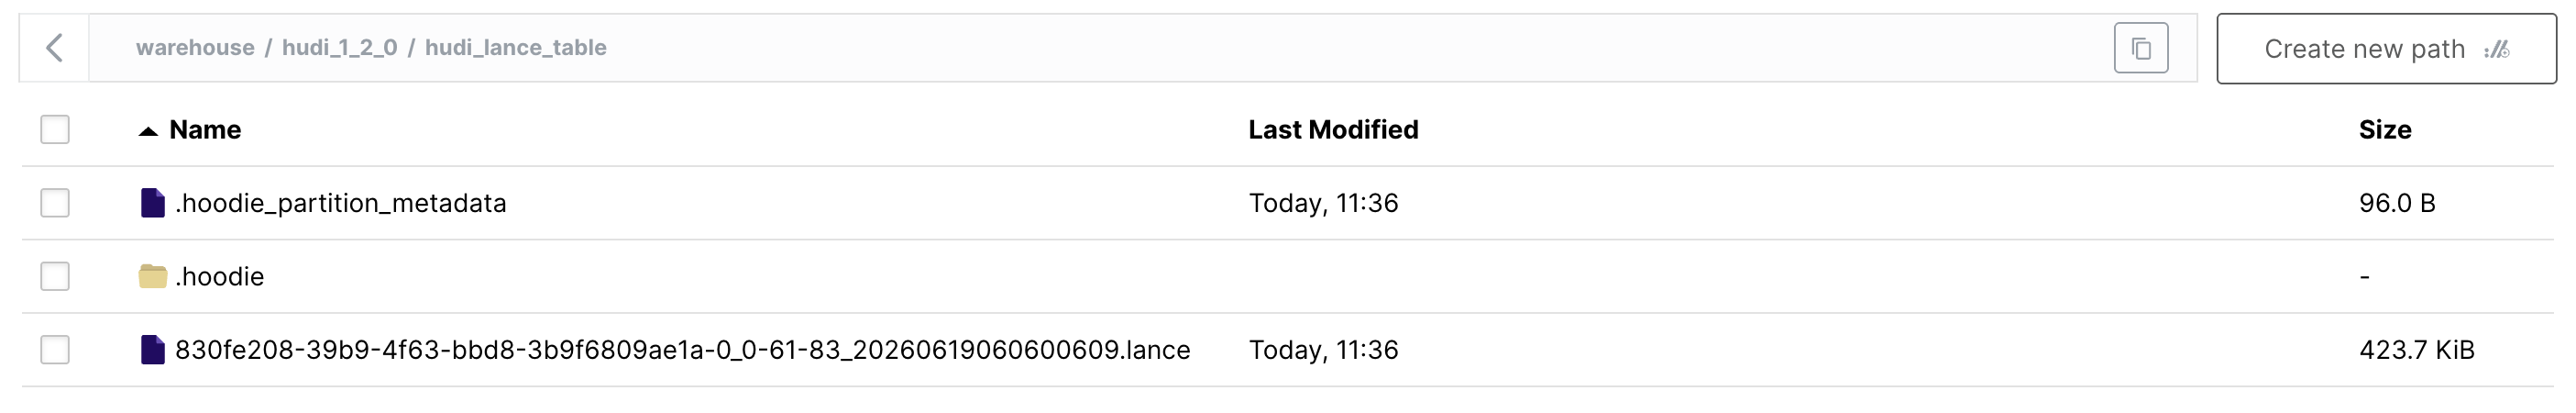

In [29]:
display(spark.sql(f"SELECT * FROM {lance_table_name}") )

_hoodie_commit_time,_hoodie_commit_seqno,_hoodie_record_key,_hoodie_partition_path,_hoodie_file_name,id,dt,name,age,score
20260622081509460,20260622081509460_0_0,1,,7d1ef351-ab89-4474-9315-f279a0e14291-0_0-179-329_20260622081509460.lance,1,2025-01-01,Alice,30,95.5
20260622081509460,20260622081509460_0_1,2,,7d1ef351-ab89-4474-9315-f279a0e14291-0_0-179-329_20260622081509460.lance,2,2025-01-02,Bob,25,87.3


In [30]:
display(spark.sql(f"SELECT id, name, age, score, dt FROM {lance_table_name}"))

id,name,age,score,dt
1,Alice,30,95.5,2025-01-01
2,Bob,25,87.3,2025-01-02


## Other 1.2.0 Highlights

Not demonstrable from a single-node Spark notebook, but worth knowing:


- **Flink Record-Level Index:** Streaming writers gain full RLI support (RECORD_LEVEL_INDEX, GLOBAL_RECORD_LEVEL_INDEX) with optional RocksDB-backed bootstrap for high throughput long-running pipelines.

- **Flink Source V2 (FLIP-27):** New opt-in source with resumable split assignment, checkpoint alignment, and stronger predicate / partition / LIMIT push-down.
  
- **Azure Storage-Based Lock Provider** — Multi-writer concurrency on ADLS Gen2 / Azure Blob Storage with **no external dependency** (no ZooKeeper or HMS lock).

- **New engine bundles** — Spark 4.1 and Flink 2.1 bundles are published in 1.2.0.

### Cleanup
Stop the SparkSession to release the standalone-cluster resources for other notebooks.

In [31]:
stop_spark_session()

SparkSession stopped successfully.


### References

1. [Hudi 1.2.0 Release Notes](https://hudi.apache.org/releases/release-1.2/)
2. [Hudi SQL DDL](https://hudi.apache.org/docs/sql_ddl)
3. [Hudi VECTOR, BLOB, and VARIANT Columns](https://hudi.apache.org/docs/next/writing_data#writing-vector-blob-and-variant-columns)
4. [Lance format](https://docs.lancedb.com/lance)